# Notebook 02 — Data Cleaning & Preprocessing

**Project:** Customer Churn ETL & Analytics Pipeline  
**Student:** Divyesh Joshi | MC24097 | MCA-II Sem IV  
**Institute:** IIMS Chinchwad, Pune — Savitribai Phule Pune University  

---

## Objective
This notebook covers **Phase 2 — Cleaning** of the ETL pipeline:
- Fix `TotalCharges` non-numeric entries
- Impute missing values
- Remove duplicates
- Standardise string columns
- Validate data quality before transformation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df_raw = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')
df = df_raw.copy()
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

Loaded: 7,043 rows x 21 columns


## 1. Fix TotalCharges Column

In [2]:
# Identify blank entries
blank_mask = df['TotalCharges'].str.strip() == ''
print(f'Blank TotalCharges entries: {blank_mask.sum()}')
print('\nAffected rows (new customers with tenure=0):')
print(df[blank_mask][['customerID','tenure','MonthlyCharges','TotalCharges']])

# Convert to numeric — blanks become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'\nAfter conversion — NaN count: {df["TotalCharges"].isna().sum()}')

Blank TotalCharges entries: 11

Affected rows (new customers with tenure=0):
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             

After conversion — NaN count: 11


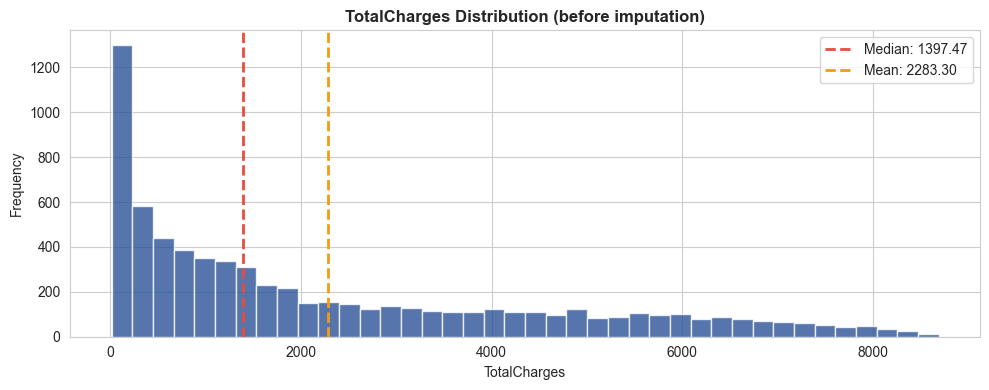

Imputed 11 values with median = 1397.47


In [3]:
# Visualise TotalCharges before imputation
median_val = df['TotalCharges'].median()
mean_val   = df['TotalCharges'].mean()

plt.figure(figsize=(10, 4))
plt.hist(df['TotalCharges'].dropna(), bins=40, color='#2a5298', edgecolor='white', alpha=0.8)
plt.axvline(median_val, color='#e74c3c', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
plt.axvline(mean_val,   color='#f39c12', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.title('TotalCharges Distribution (before imputation)', fontweight='bold')
plt.xlabel('TotalCharges'); plt.ylabel('Frequency')
plt.legend(); plt.tight_layout(); plt.show()

# Impute with median (robust to skew)
df['TotalCharges'] = df['TotalCharges'].fillna(median_val)
print(f'Imputed {blank_mask.sum()} values with median = {median_val:.2f}')

## 2. Remove Duplicate Rows

In [4]:
before = len(df)
df.drop_duplicates(inplace=True)
after  = len(df)
print(f'Before: {before:,} rows')
print(f'After:  {after:,} rows')
print(f'Removed: {before - after} duplicate rows')

Before: 7,043 rows
After:  7,043 rows
Removed: 0 duplicate rows


## 3. Standardise String Columns

In [5]:
str_cols = df.select_dtypes('object').columns.tolist()
print(f'String columns to clean ({len(str_cols)}): {str_cols}')

for col in str_cols:
    df[col] = df[col].str.strip()

print('\nStripped whitespace from all string columns.')

String columns to clean (17): ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Stripped whitespace from all string columns.


## 4. Post-Cleaning Validation

In [6]:
print('=== Post-Cleaning Validation ===')
print(f'Shape:            {df.shape}')
print(f'Total null values: {df.isnull().sum().sum()}')
print(f'Duplicate rows:   {df.duplicated().sum()}')
print(f'TotalCharges dtype: {df["TotalCharges"].dtype}')
print('\nAll checks passed!' if df.isnull().sum().sum() == 0 else 'WARNING: Nulls remain!')

=== Post-Cleaning Validation ===
Shape:            (7043, 21)
Total null values: 0
Duplicate rows:   0
TotalCharges dtype: float64

All checks passed!


## 5. Before vs After Comparison

In [7]:
comparison = pd.DataFrame({
    'Metric':  ['Total Rows', 'Null Values', 'Duplicate Rows', 'TotalCharges dtype'],
    'Before':  [df_raw.shape[0], df_raw.isnull().sum().sum() + blank_mask.sum(),
                df_raw.duplicated().sum(), 'object (string)'],
    'After':   [df.shape[0], df.isnull().sum().sum(),
                df.duplicated().sum(), 'float64']
})
print(comparison.to_string(index=False))

            Metric          Before   After
        Total Rows            7043    7043
       Null Values              11       0
    Duplicate Rows               0       0
TotalCharges dtype object (string) float64


## 6. Save Cleaned Data

In [8]:
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/churn_cleaned_nb.csv', index=False)
print('Cleaned data saved to ../data/processed/churn_cleaned_nb.csv')

Cleaned data saved to ../data/processed/churn_cleaned_nb.csv


## 7. Summary

| Step | Action | Result |
|---|---|---|
| TotalCharges fix | Convert to numeric, impute with median | 11 entries fixed |
| Duplicates | drop_duplicates() | 0 removed |
| String standardisation | str.strip() on all object columns | Whitespace removed |
| Final shape | — | 7,043 rows x 21 columns |

**Next Step → Notebook 03: Feature Engineering & Transformation**